### The Goal: Analyze "automobile sales" using matplotlib and seaborn to understand the historical trend during recession periods

period1 - 1980   
period2 - 1981 to 1982    
period3 - 1991    
period4 - 2000 to 2001   
period5 - end of 2007 to mid 2009    
period6 - Feb to April of 2020




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

The data for this project is gotten from IBM Skills Network Labs.

The dataset includes the following variables:
1. Date: The month end date of sales observation.   
2. Recession: A binary variable indicating recession perion; 1 means it was recession, 0 means it was normal.   
3. Automobile_Sales: The number of vehicles sold during the period.   
4. GDP: The per capita GDP value in USD.   
5. Unemployment_Rate: The monthly unemployment rate.   
6. Consumer_Confidence: A synthetic index representing consumer confidence, which can impact consumer spending and automobile purchases.   
7. Seasonality_Weight: The weight representing the seasonality effect on automobile sales during the period. This variable represents the seasonal effect on automobile sales for a given month. In the automobile industry, sales often fluctuate throughout the year due to seasonal patterns—for example, sales may increase during the festive season or year-end promotions, and decrease during off-peak months like post-holiday winter periods. A value greater than 1 indicates higher-than-average sales expected for that month due to seasonal trends (e.g., holiday season or new model launches). A value less than 1 suggests lower-than-average sales due to seasonal slowdowns. A value around 1 means the season has neutral or average effect on sales.   
8. Price: The average vehicle price during the period.   
9. Advertising_Expenditure: The advertising expenditure of the company.   
10.Vehicle_Type: The type of vehicles sold; Supperminicar, Smallfamiliycar, Mediumfamilycar, Executivecar, Sports.   
11.Competition: The measure of competition in the market, such as the number of competitors or market share of major manufacturers.   
12.Month: Month of the observation extracted from Date.   
13.Year: Year of the observation extracted from Date.   

In [2]:
df = pd.read_csv('automobile_sales.csv')
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


In [3]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [4]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

## 1. How does the average autombiles sales fluctuate from year to year?

In [5]:
yr = df.groupby('Year')['Automobile_Sales'].sum().reset_index()
yr

,Year,Automobile_Sales
0,1980,25960.90
1,1981,23614.32
2,1982,37313.00
3,1983,213163.00
4,1984,188863.00
5,1985,205234.00
6,1986,123990.00
7,1987,142581.00
8,1988,203459.00
9,1989,208446.00


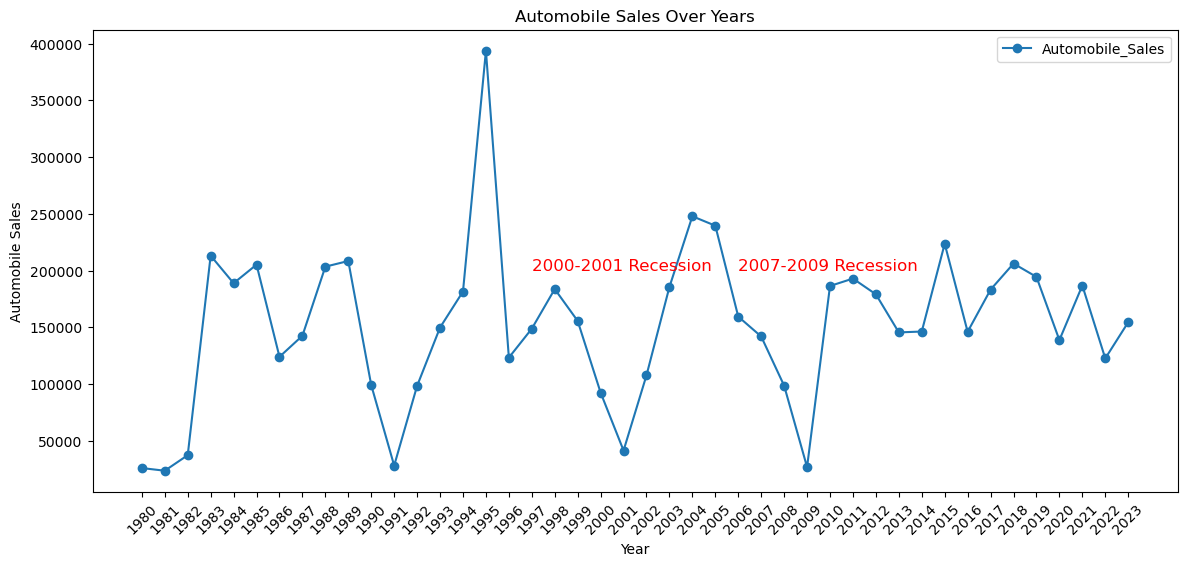

In [33]:
yr.plot(kind='line', x='Year', y='Automobile_Sales', title='Automobile Sales Over Years', marker='o', figsize=(14, 6))
plt.xlabel('Year')
plt.ylabel('Automobile Sales')
plt.xticks(yr['Year'], rotation=45)
plt.text(1997, 200000, '2000-2001 Recession', fontsize=12, color='red')
plt.text(2006, 200000, '2007-2009 Recession', fontsize=12, color='red')
plt.legend()
plt.show()

## 2. How does trends in advertising expenditure correlate with automobile sales during non-recession periods and what insights can be derived from this relationship?

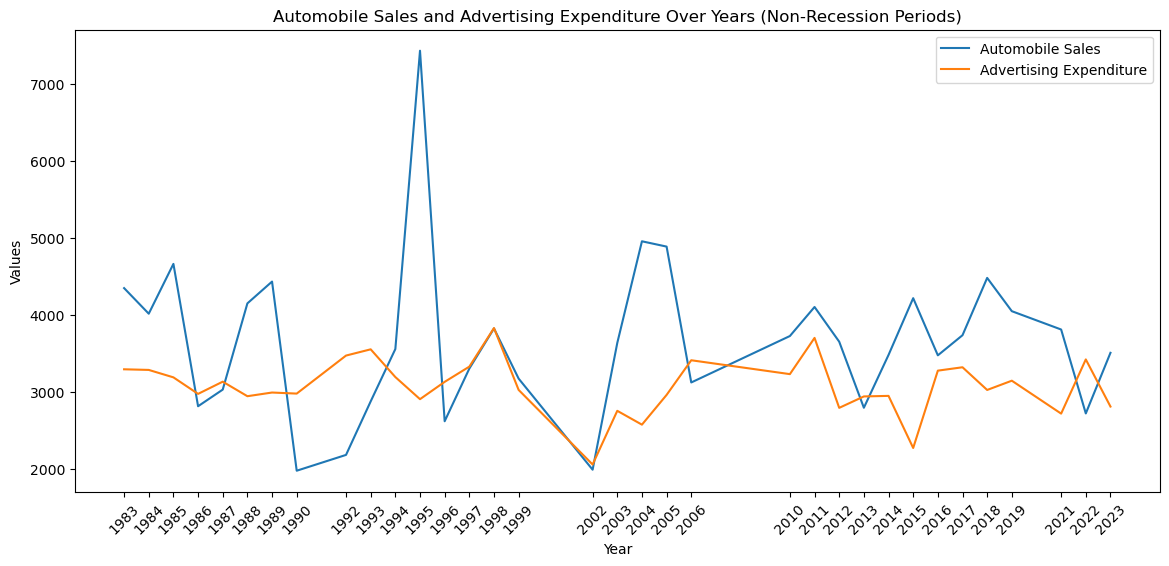

In [42]:
non_rec = df[df['Recession'] == 0]
exp_sales = non_rec.groupby('Year')[['Automobile_Sales', 'Advertising_Expenditure']].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=exp_sales, x='Year', y='Automobile_Sales', label='Automobile Sales')
sns.lineplot(data=exp_sales, x='Year', y='Advertising_Expenditure', label='Advertising Expenditure')
plt.title('Automobile Sales and Advertising Expenditure Over Years (Non-Recession Periods)')
plt.xlabel('Year')
plt.ylabel('Values')
plt.xticks(exp_sales['Year'], rotation=45)
plt.legend()
plt.show()

From the plot above, we can see that automobile sales are more volatile than advertising expenditure. The correlation over time between the two variables is inconsistent

## 3. Sales Trend per Vehicle type for recession period vs non recession period

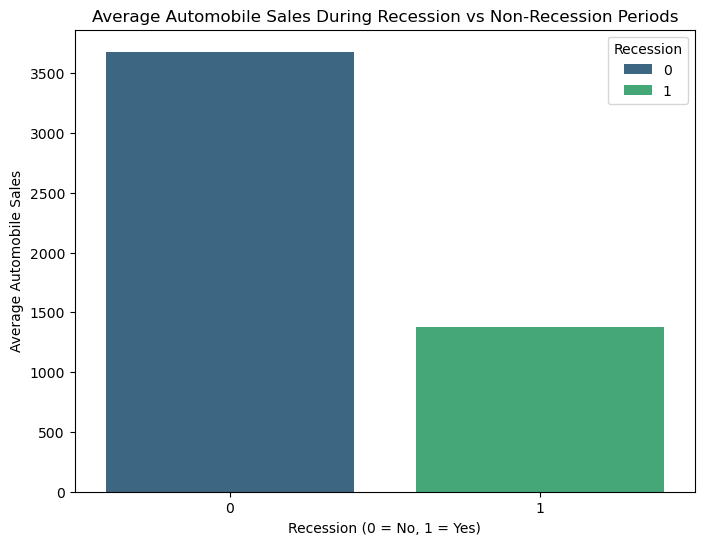

In [46]:
sales_vehicle = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=sales_vehicle, x='Recession', y='Automobile_Sales', hue='Recession', palette='viridis')
plt.title('Average Automobile Sales During Recession vs Non-Recession Periods')
plt.xlabel('Recession (0 = No, 1 = Yes)')
plt.ylabel('Average Automobile Sales')
plt.show()

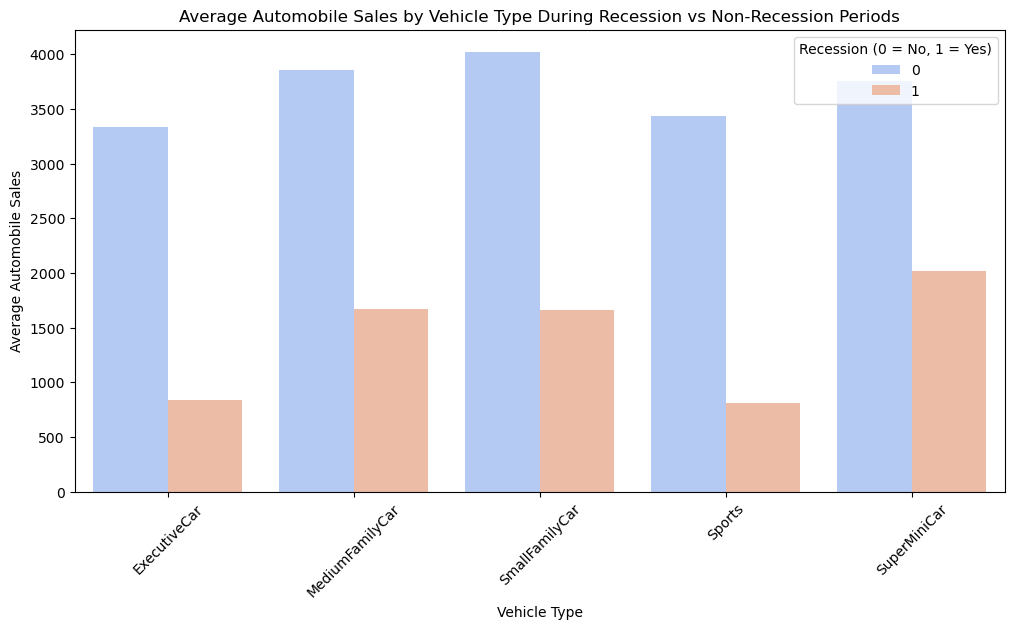

In [47]:
# compare the sales of different vehicle types during recession and non-recession periods
vehicle_sales = df.groupby(['Vehicle_Type', 'Recession'])['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=vehicle_sales, x='Vehicle_Type', y='Automobile_Sales', hue='Recession', palette='coolwarm')
plt.title('Average Automobile Sales by Vehicle Type During Recession vs Non-Recession Periods')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Automobile Sales')
plt.xticks(rotation=45)
plt.legend(title='Recession (0 = No, 1 = Yes)')
plt.show()

As expected, the overal sales of cars is less during periods of recession. However, Super mini cars reportedly sell the most during recession periods, while small family cars sell the most during non-recession. The most affected kind of vehicle is the executive and sport cars

## 4. How did the GDP vary over time during recession and non-recession periods?

In [48]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

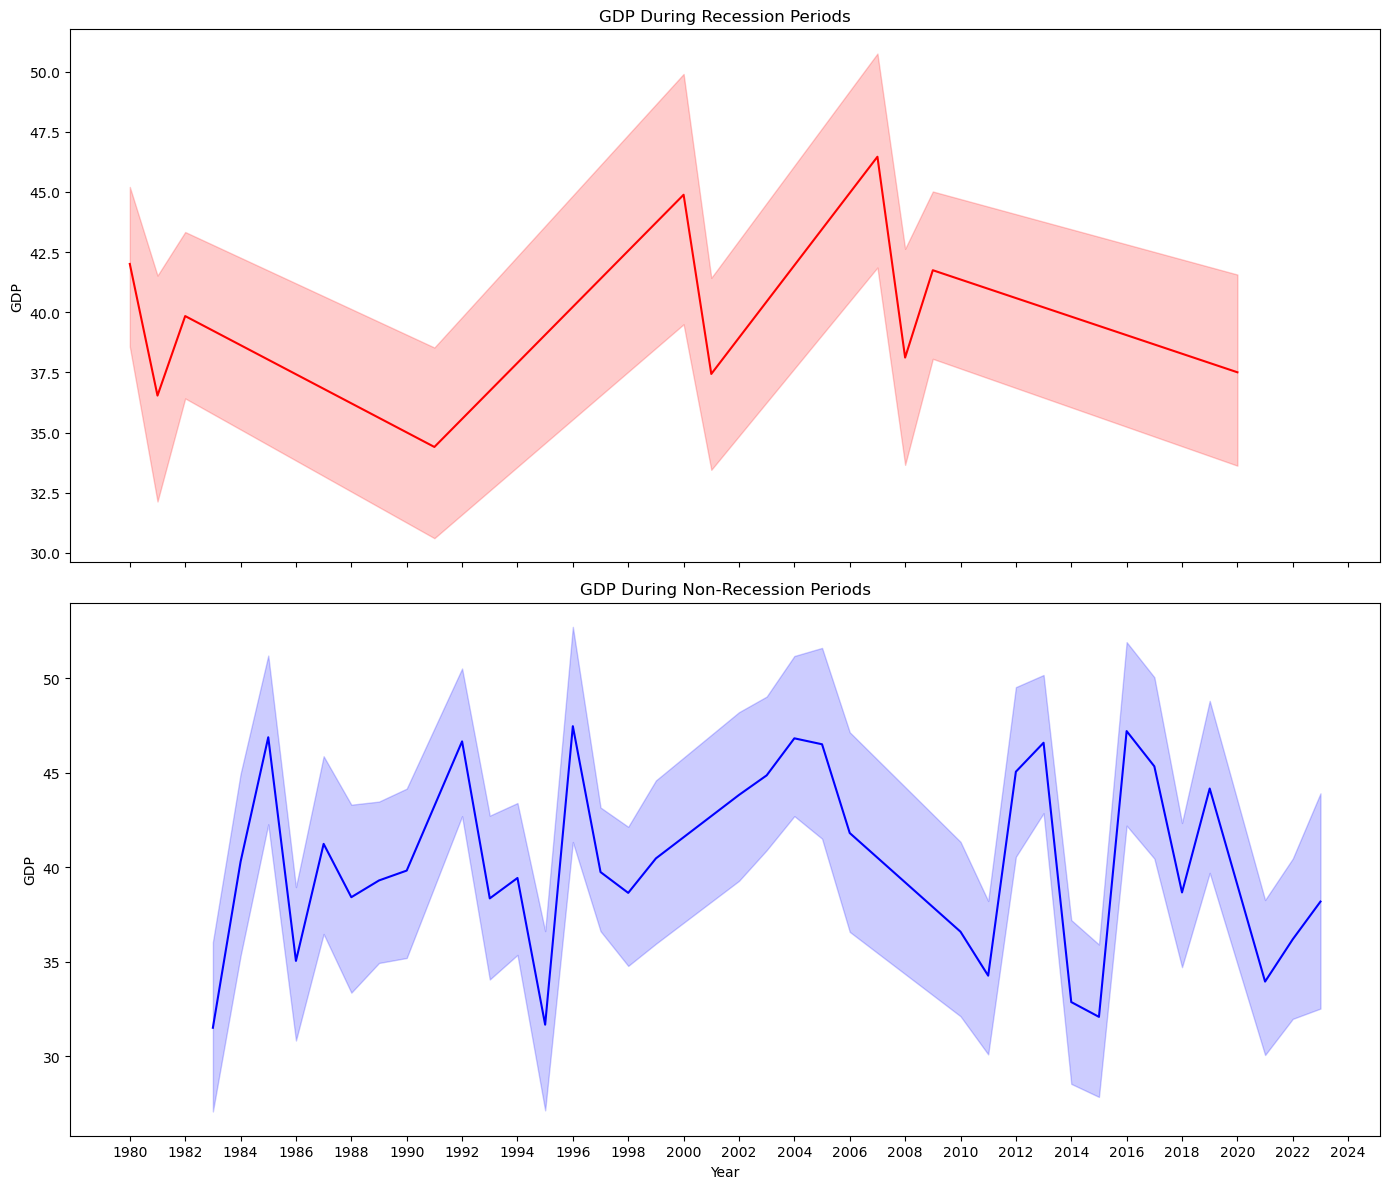

In [70]:
fig, ax = plt.subplots(2, 1,figsize=(14,12), sharex=True)

rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]


sns.lineplot(data=rec_data, x='Year', y='GDP', color='red', ax=ax[0])
ax[0].set_title('GDP During Recession Periods')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('GDP')

sns.lineplot(data=non_rec_data, x='Year', y='GDP', color='blue', ax=ax[1])
ax[1].set_title('GDP During Non-Recession Periods')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('GDP')
ax[1].set_xticks(list(range(1980, 2025, 2))) 

plt.tight_layout()
plt.show()


From the comparison above, GDP tend lower during recessions andhighly volatile. GDP during non-recession also show some level of volatility

## 5. How has seasonality impacted slaes, in which months were the sales high or low

In [71]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

In [73]:
seasonal_sales = non_rec_data.groupby(['Year', 'Month'])['Automobile_Sales'].sum().reset_index()
seasonal_sales

,Year,Month,Automobile_Sales
0,1983,Apr,16095.0
1,1983,Aug,20722.0
2,1983,Dec,50031.0
3,1983,Feb,9459.0
4,1983,Jan,905.0
...,...,...,...
403,2023,Mar,20377.0
404,2023,May,16354.0
405,2023,Nov,8449.0
406,2023,Oct,6750.0


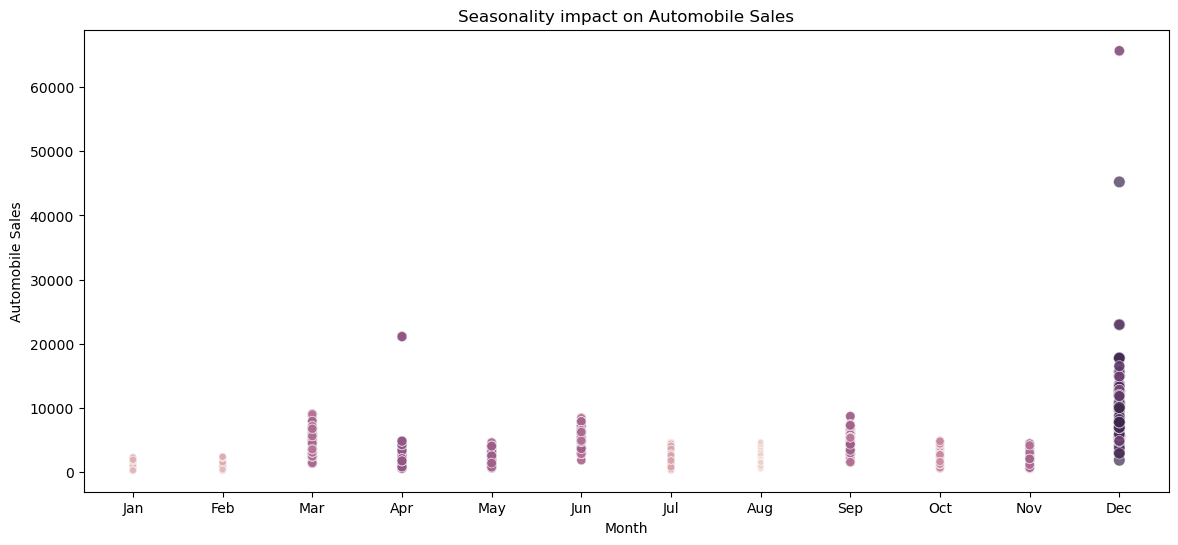

In [82]:
plt.figure(figsize=(14, 6))
sns.scatterplot(data=non_rec_data, x='Month', y='Automobile_Sales', size='Seasonality_Weight', hue='Seasonality_Weight', alpha=0.7, legend=False)
plt.title('Seasonality impact on Automobile Sales')
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.show()

From the Seasonality buble plot, across all non-recession periods, the month of december seems to experience the largest amount of car sales, while August experiences the least

## 6. What is the relationship between consumer confidence and automobile sales during recession periods?

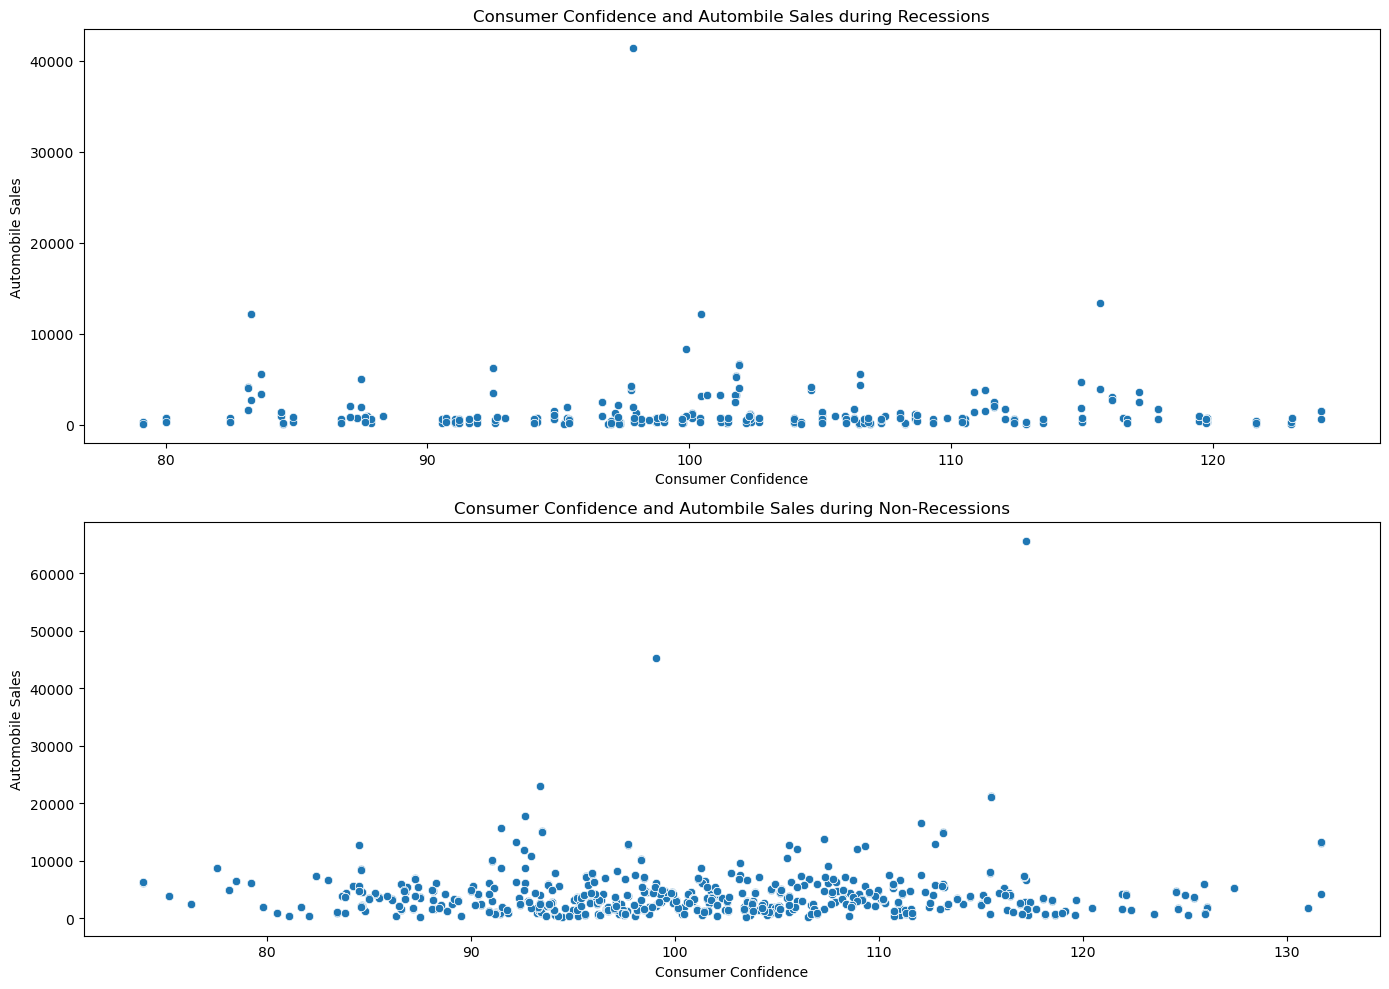

In [103]:
rec_data = df[df['Recession']==1]
non_rec_data = df[df['Recession'] == 0]

fig, ax = plt.subplots(2, 1, figsize=(14, 10))
ax1 = sns.scatterplot(data=rec_data, x='Consumer_Confidence' ,y='Automobile_Sales', ax=ax[0])
ax1.set_title('Consumer Confidence and Autombile Sales during Recessions')
ax1.set_xlabel('Consumer Confidence')
ax1.set_ylabel('Automobile Sales')

ax2 = sns.scatterplot(data=non_rec_data, x='Consumer_Confidence' ,y='Automobile_Sales', ax=ax[1])
ax2.set_title('Consumer Confidence and Autombile Sales during Non-Recessions')
ax2.set_xlabel('Consumer Confidence')
ax2.set_ylabel('Automobile Sales')

plt.tight_layout()
plt.show()

There is not established relationship between consumer confidence and automobile sales and consumer confidence in periods of recession. This can be verified by calculating the correlation coefficient between the two features below. A correlation coefficient extremely close to 0 shows no linear correlation between the two variables

In [104]:
cnf_cons = rec_data['Consumer_Confidence'].corr(rec_data['Automobile_Sales'])
abs(cnf_cons.item())

0.05032029619276066

We can also evaluate the relationship between the average prices of cars and the actual sales during this period

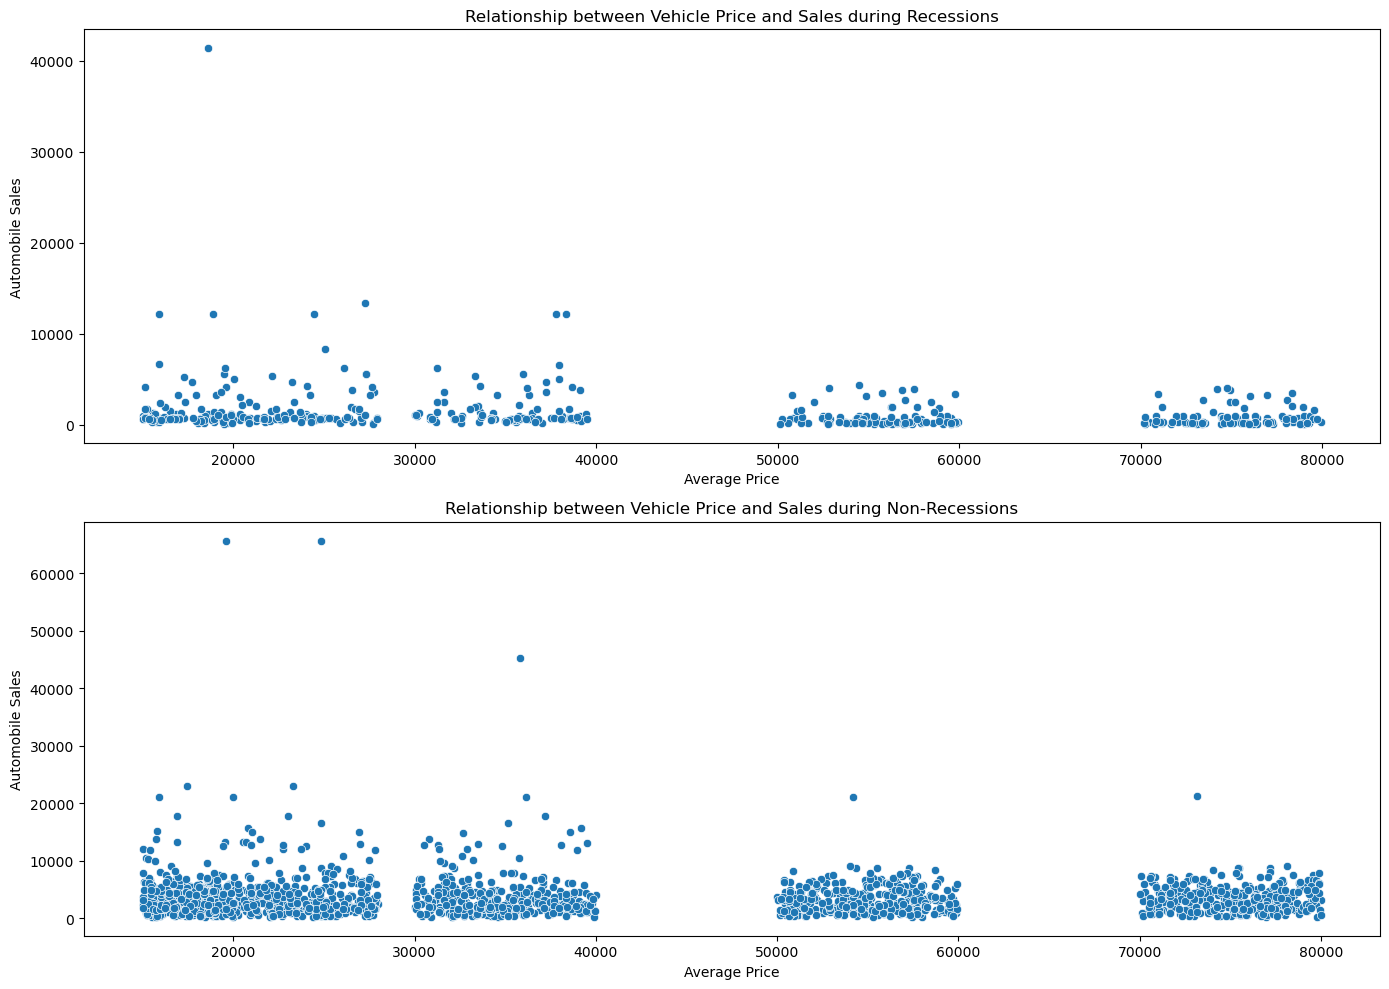


-----Correlation Between Price and Sales during Recession-----

                     Price  Automobile_Sales
Price             1.000000         -0.167156
Automobile_Sales -0.167156          1.000000

-----Correlation Between Price and Sales during Non-Recession-----

                    Price  Automobile_Sales
Price             1.00000          -0.05747
Automobile_Sales -0.05747           1.00000


In [108]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

ax1 = sns.scatterplot(data=rec_data, x='Price', y='Automobile_Sales', ax=ax[0])
ax1.set_title('Relationship between Vehicle Price and Sales during Recessions')
ax1.set_xlabel('Average Price')
ax1.set_ylabel('Automobile Sales')

ax2 = sns.scatterplot(data=non_rec_data, x='Price', y='Automobile_Sales', ax=ax[1])
ax2.set_title('Relationship between Vehicle Price and Sales during Non-Recessions')
ax2.set_xlabel('Average Price')
ax2.set_ylabel('Automobile Sales')

plt.tight_layout()
plt.show()

rec_price_sales_corr = rec_data[['Price', 'Automobile_Sales']].corr()
nonrec_price_sales_corr = non_rec_data[['Price', 'Automobile_Sales']].corr()

print('\n-----Correlation Between Price and Sales during Recession-----\n')
print(rec_price_sales_corr)

print('\n-----Correlation Between Price and Sales during Non-Recession-----\n')
print(nonrec_price_sales_corr)

Suprisingly, the plot indicates that sales of cars and the prices are weakly correlated. The pearson coefficient supports this result with a value of ~`-0.167` during recession and `-0.057` in Non recession

## 7. How did advertising expenditure of XYZAutomotives changes during recession and non-recession periods?

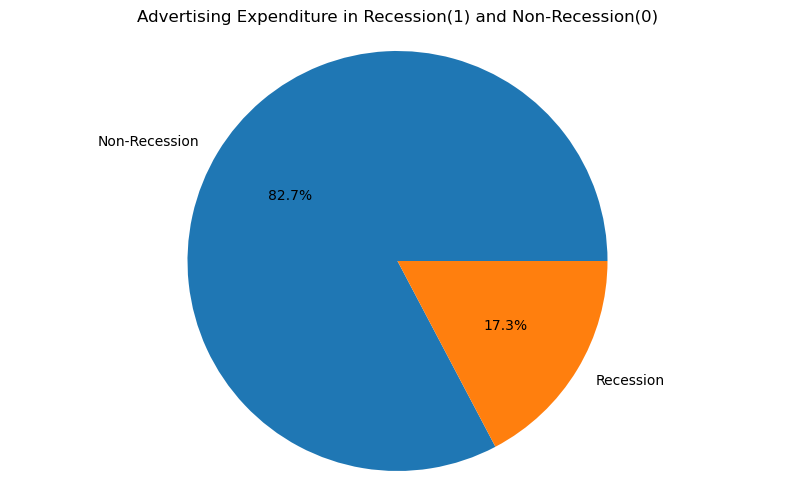

In [118]:
ads_ = df.groupby('Recession')['Advertising_Expenditure'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.pie(ads_['Advertising_Expenditure'], labels=['Non-Recession','Recession'], autopct='%1.1f%%')
plt.title('Advertising Expenditure in Recession(1) and Non-Recession(0)')
plt.axis('equal')
plt.show()

Advertising expenditure for recession period is 17.3% of the total expenditure, compared to 82.7% during non-recession periods. The company spends more during non-recesion periods comapred to recession periods